<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Testing a Simple Regression Model

*The setup:* predicting SPY's daily return using two macro predictors — VIX and the 10Y-2Y yield curve slope — via ordinary least squares.

*The pipeline:*
1. ***Target:*** SPY daily returns, computed from adjusted close prices via compute_returns.
2. ***Predictors:*** VIX and yield slope, pulled from FRED, aligned to SPY's trading-day index and forward-filled where frequencies don't match exactly.
3. ***Feature matrix:*** build_feature_matrix combines the target and predictors into one aligned DataFrame, with per-predictor lags configurable (currently set to 0 — same-day, contemporaneous values) and any row with missing data dropped.
4. ***Model:*** fit_ols runs a standard OLS regression via statsmodels, giving full statistical output with coefficients, t-stats, p-values, R².
___
Note that this is a weak pairing by design. VIX and yield slope aren't strong predictors of *next-day return* specifically (they're much better suited to predicting volatility, or operating over longer horizons). A low R² here is expected; this is simply a low-stakes first test to confirm all mechanics work cleanly before layering in lags, more predictors, or switching the target to volatility.

</div>

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

from src.fetch_data import fetch_spy_prices, fetch_macro_predictors, save_data

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
spy_prices = fetch_spy_prices()
spy_prices.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close
Date,
2026-07-29,729.460022
2026-07-30,741.690002
2026-07-31,747.030029
2026-08-03,757.669983
2026-08-04,771.330017


In [5]:
macro_df = fetch_macro_predictors()
macro_df.tail()

Fetching VIX (VIXCLS)...
Fetching Yield_Slope (T10Y2Y)...


,VIX,Yield_Slope
2026-07-30,17.09,0.45
2026-07-31,15.99,0.47
2026-08-03,15.86,0.45
2026-08-04,16.50,0.43
2026-08-05,NaN,0.45


In [6]:
from src.fetch_data import fetch_spy_prices, fetch_macro_predictors
from src.features import compute_returns, build_feature_matrix
from src.regression import fit_ols
from src.evaluation import summarize_ols, compute_residual_diagnostics
from src.visualize import plot_actual_vs_fitted, plot_residuals

spy_prices = fetch_spy_prices()
macro_df = fetch_macro_predictors()

spy_returns = compute_returns(spy_prices)
feature_df = build_feature_matrix(spy_returns, macro_df, lags={"VIX": 0, "Yield_Slope": 0})
feature_df.tail()

[*********************100%***********************]  1 of 1 completed


Fetching VIX (VIXCLS)...
Fetching Yield_Slope (T10Y2Y)...


,target,VIX,Yield_Slope
Date,,,
2026-07-29,-0.015387,20.66,0.45
2026-07-30,0.016766,17.09,0.45
2026-07-31,0.007200,15.99,0.47
2026-08-03,0.014243,15.86,0.45
2026-08-04,0.018029,16.50,0.43


In [7]:
model = fit_ols(feature_df, predictor_cols=["VIX", "Yield_Slope"])
summary, r2, r2_adj = summarize_ols(model)
print(f"R-squared: {r2:.4f}, Adjusted R-squared: {r2_adj:.4f}")
summary.round(4)

R-squared: 0.0270, Adjusted R-squared: 0.0265


,coefficient,std_err,t_stat,p_value,significant
const,0.0054,0.0005,10.5951,0.0000,True
VIX,-0.0003,0.0000,-10.7434,0.0000,True
Yield_Slope,-0.0000,0.0002,-0.0068,0.9946,False


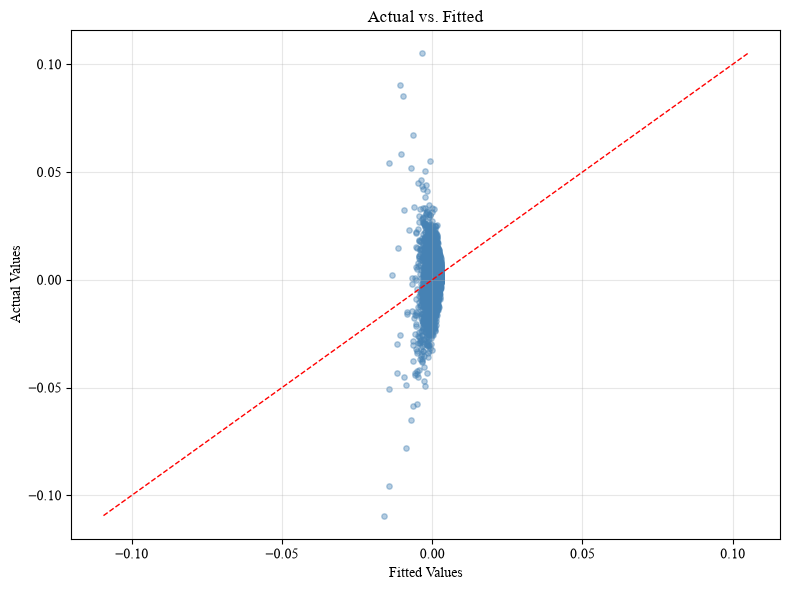

In [8]:
plot_actual_vs_fitted(model)

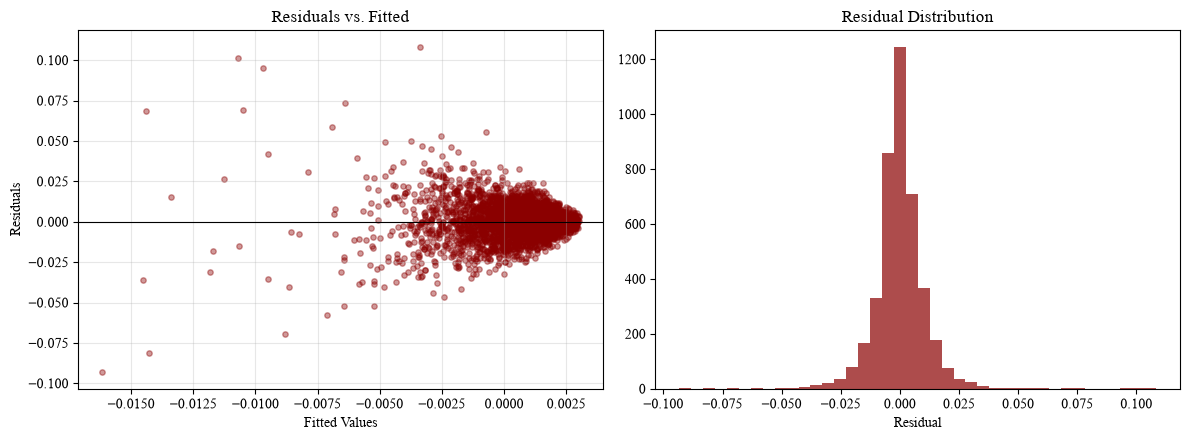

In [9]:
residual_df = compute_residual_diagnostics(model)
plot_residuals(residual_df)

In [21]:
from src.optimization import run_grid_search_parallel
from src.evaluation import evaluate_regression_combo
from src.features import build_lag_grid, split_lag_columns

predictor_names = ["VIX", "Yield_Slope"]

lag_configs = build_lag_grid(predictor_names, lag_range=list(range(0, 21)))
horizons = [1, 3, 5, 10, 15, 20, 25, 30, 35, 40]

param_grid = {
    "horizon": horizons,
    "lags": lag_configs,
}

total_combos = len(horizons) * len(lag_configs)
print(f"Total combinations: {total_combos}")

grid_results = run_grid_search_parallel(
    evaluate_regression_combo,
    param_grid,
    fixed_args={
        "predictor_cols": predictor_names,
        "spy_prices": spy_prices,
        "macro_df": macro_df,
    },
    n_jobs=6,
)

grid_results = split_lag_columns(grid_results, predictor_names)
grid_results.sort_values("r_squared", ascending=False).head(10)

Total combinations: 4410
Running 4410 combinations across 6 processes...


,horizon,r_squared,r_squared_adj,n_obs,VIX_lag,Yield_Slope_lag
4031,40,0.086620,0.086175,4112,2,20
4030,40,0.086594,0.086149,4113,2,19
4027,40,0.086581,0.086137,4116,2,16
4029,40,0.086579,0.086134,4114,2,18
4028,40,0.086556,0.086112,4115,2,17
4026,40,0.086534,0.086090,4117,2,15
4025,40,0.086426,0.085982,4118,2,14
4024,40,0.086357,0.085913,4119,2,13
4071,40,0.086354,0.085909,4114,4,18
4072,40,0.086327,0.085882,4113,4,19


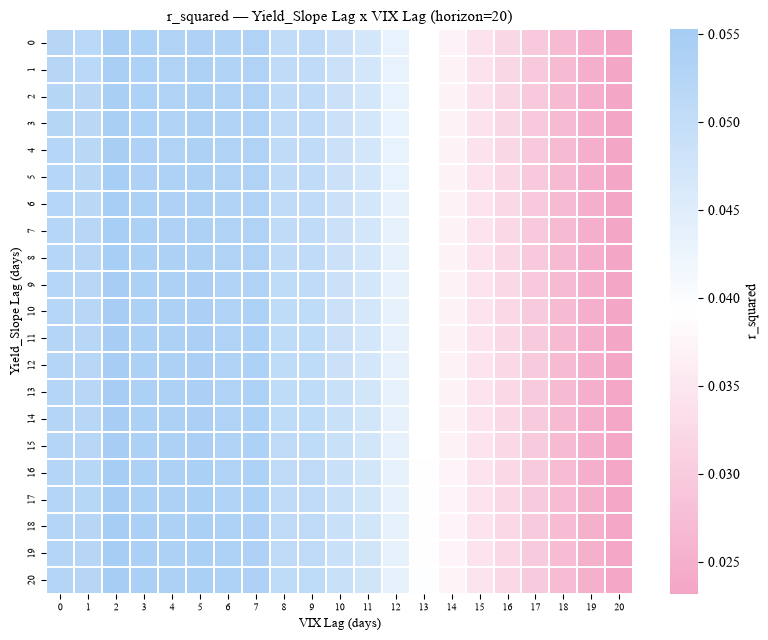

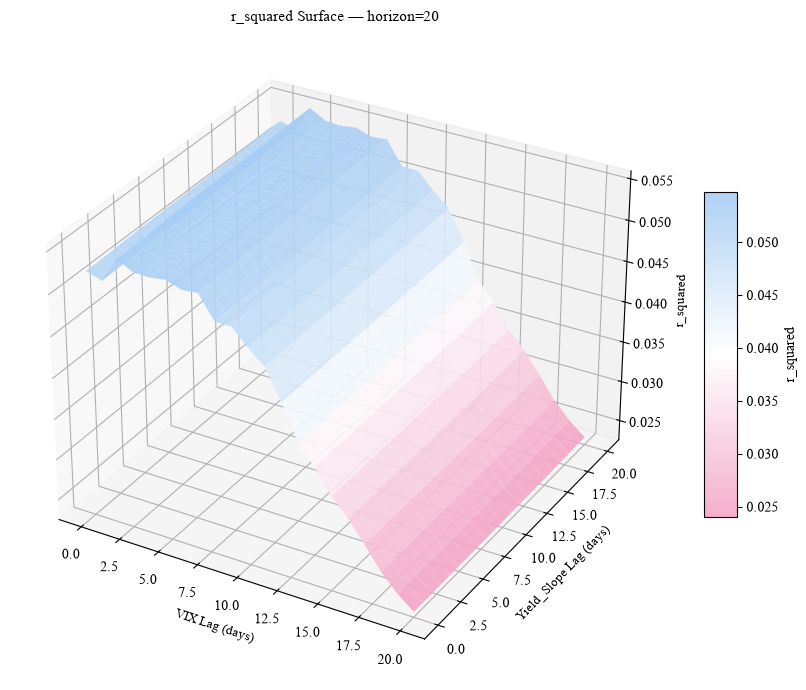

In [23]:
from src.visualize import plot_lag_heatmap, plot_lag_surface_3d

plot_lag_heatmap(grid_results, horizon=20, predictor_x="VIX", predictor_y="Yield_Slope")
plot_lag_surface_3d(grid_results, horizon=20, predictor_x="VIX", predictor_y="Yield_Slope")

<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Sector Breakdown

</div>


In [24]:
from src.fetch_data import fetch_sector_etf_prices, fetch_macro_predictors

SECTOR_ETFS = {
    "Technology": "XLK",
    "Financials": "XLF",
    "Energy": "XLE",
    "Health Care": "XLV",
    "Consumer Discretionary": "XLY",
    "Consumer Staples": "XLP",
    "Industrials": "XLI",
    "Utilities": "XLU",
    "Materials": "XLB",
    "Real Estate": "XLRE",
    "Communication Services": "XLC",
}

sector_prices = fetch_sector_etf_prices(SECTOR_ETFS)
macro_df = fetch_macro_predictors()

Fetching Technology (XLK)...


[*********************100%***********************]  1 of 1 completed


Fetching Financials (XLF)...


[*********************100%***********************]  1 of 1 completed


Fetching Energy (XLE)...


...

Fetching Real Estate (XLRE)...


[*********************100%***********************]  1 of 1 completed


Fetching Communication Services (XLC)...


[*********************100%***********************]  1 of 1 completed


Fetching VIX (VIXCLS)...
Fetching Yield_Slope (T10Y2Y)...


In [25]:
from src.evaluation import find_best_regression_by_sector, summarize_sector_results

sector_results = find_best_regression_by_sector(
    sector_prices, macro_df,
    predictor_cols=["VIX", "Yield_Slope"],
    horizons=[1, 5, 10, 20, 30, 40],
    lag_range=[0, 1, 3, 5, 10],
)

summary_df = summarize_sector_results(sector_results)
summary_df.round(4)

Finding best regression for Technology...
Finding best regression for Financials...
Finding best regression for Energy...
Finding best regression for Health Care...
Finding best regression for Consumer Discretionary...
Finding best regression for Consumer Staples...
Finding best regression for Industrials...
Finding best regression for Utilities...
Finding best regression for Materials...
Finding best regression for Real Estate...
Finding best regression for Communication Services...


,Sector,R_squared,Horizon,VIX_lag,Yield_Slope_lag,VIX_coef,VIX_pvalue,Yield_Slope_coef,Yield_Slope_pvalue
10,Communication Services,0.1152,40,3,10,0.0033,0.0,-0.0240,0.0000
8,Materials,0.1096,40,3,5,0.0034,0.0,0.0013,0.2198
2,Energy,0.0967,40,3,10,0.0048,0.0,0.0001,0.9658
6,Industrials,0.0910,40,10,0,0.0030,0.0,0.0004,0.6930
0,Technology,0.0876,40,0,10,0.0031,0.0,-0.0066,0.0000
4,Consumer Discretionary,0.0788,40,3,0,0.0029,0.0,0.0037,0.0010
9,Real Estate,0.0538,40,3,0,0.0016,0.0,0.0179,0.0000
5,Consumer Staples,0.0492,40,0,1,0.0012,0.0,0.0050,0.0000
3,Health Care,0.0353,30,0,5,0.0012,0.0,0.0036,0.0000
1,Financials,0.0332,40,10,10,0.0019,0.0,-0.0032,0.0069
